# Analyze and plot results for networks

This script takes in the results from run_over_regs.sh, assembles them into a single dataset, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
from pydmd import DMD
import os
import plotly.graph_objects as go
import plotly.express as px

# import clustering packages
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import seaborn as sns
from celluloid import Camera

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
sim_kind = 'agent'
infection_type = 'sec'
reg_model = ''
runs = '-10-'
comment = "Nact-reg-Ediv-reg" #'mem-reg'

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'
d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/std/processed_data'+runs+'runs'+'-'+comment+'.pkl'


clustered_mean_df = pd.read_pickle(d_mean)
std_df = pd.read_pickle(d_std)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,S_0,I_0,b_I,d_S,d_I,d_IE,d_IH,K_IE,K_IH,Aout_0,b_Ain,b_H,d_H,K_EI,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_act,t_bind,t_Na_div,t_E_div,t_M_div,t_M_diff,t_E_die,t_E_cyt,psi_Nact_I,psi_Nact_H,psi_Nact_IH,psi_NM_I,psi_NM_H,psi_NM_IH,psi_EM_I,psi_EM_H,psi_EM_IH,psi_Ediv_I,psi_Ediv_H,psi_Ediv_IH,p_load,s_load,T_max_pI,T_max_sI,harm_pI,harm_sI,harm_pS,harm_sS,max_pE,max_sE,T_max_pE,T_max_sE,inf_pM,inf_sM,init_M,int_pE,int_sE,int_pH,int_sH,min_pS,min_sS,harm_pI_scaled,harm_sI_scaled,harm_pS_scaled,harm_sS_scaled,harm_pIS,harm_sIS,harm_pIS_scaled,harm_sIS_scaled,harm_totIS_scaled,max_pE_scaled,max_sE_scaled,int_pE_scaled,int_sE_scaled,inf_pmem,inf_smem,inf_pmem_scaled,inf_smem_scaled,inf_pM_scaled,inf_sM_scaled,init_M_scaled,harm_I_fld_chg,harm_I_diff_chg,max_presp_scaled,max_sresp_scaled,max_totresp_scaled,int_presp_scaled,int_sresp_scaled,int_totresp_scaled,max_presp,max_sresp,max_totresp,int_presp,int_sresp,int_totresp,d_I_K_IE,no_reg,bio_reg,peff_protection,seff_protection,peff_toxicity,seff_toxicity,peff_utility,seff_utility,peff_efficiency,seff_efficiency,peff_protection_frac,seff_protection_frac,peff_protection_log,seff_protection_log,high_putility,high_ptoxicity,high_presponse,high_pefficiency,high_sutility,high_stoxicity,high_sresponse,high_sefficiency
0,10000000.0,0.0,1.250000e-07,0.01,0.0,12.0,0.0,1000000.0,4444.444444,1000.0,1.0,1.0,2.0,1000000.0,4444.444444,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.6,2.000000e-01,1.2,0.0,0.0,0.0,0.0,0.0,0.0,-8.000000e-01,0.8,-4.000000e-01,0.000000e+00,0.000000e+00,0.0000,0.0000,0.000000e+00,0.000000e+00,31424.985737,28342.222005,177.3,271.3,5.4824,3.9956,17.3,12.5,4.9,852.2664,5.696204e+02,1.106510e+04,1.106482e+04,9.972455e+06,9.973043e+06,0.000000,0.000000,0.314250,0.283422,3.142499e+04,2.834222e+04,0.314250,0.283422,0.597672,0.000177,0.000271,0.000852,0.000570,34.6,25.0,0.000035,0.000025,0.000013,0.000013,0.000005,1.000059,0.000059,0.000190,0.000284,0.000474,0.000865,0.000582,0.001149,194.6,283.8,478.4,869.5664,5.821204e+02,1.153366e+03,0,True,0,0.000000,0.000000,0.314250,0.283422,-0.092936,-0.062109,NaN,NaN,NaN,NaN,NaN,inf,0,0,0,0,0,0,0,0
5,10000000.0,0.0,1.250000e-07,0.01,0.0,12.0,0.0,1000000.0,4444.444444,1000.0,1.0,1.0,2.0,1000000.0,4444.444444,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,0.6,-6.000000e-01,0.8,0.0,0.0,0.0,0.0,0.0,0.0,-1.321109e-16,-1.2,8.000000e-01,0.000000e+00,0.000000e+00,0.0000,0.0000,0.000000e+00,0.000000e+00,35888.916890,31272.361522,263.9,291.9,7.2336,5.6352,31.3,17.1,7.8,1261.5820,8.384124e+02,1.106520e+04,1.106407e+04,9.968484e+06,9.971058e+06,0.000000,0.000000,0.358889,0.312724,3.588892e+04,3.127236e+04,0.358889,0.312724,0.671613,0.000264,0.000292,0.001262,0.000838,62.6,34.2,0.000063,0.000034,0.000017,0.000017,0.000008,1.000258,0.000258,0.000281,0.000309,0.000590,0.001279,0.000856,0.001588,295.2,309.0,604.2,1292.8820,8.555124e+02,1.601882e+03,0,True,0,0.000000,0.000000,0.358889,0.312724,-0.137576,-0.091410,NaN,NaN,NaN,NaN,NaN,inf,0,0,0,0,0,0,0,0
10,10000000.0,0.0,1.250000e-07,0.01,0.0,12.0,0.0,1000000.0,4444.444444,1000.0,1.0,1.0,2.0,1000000.0,4444.444444,100.0,8.0,2123.238243,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,25.0,2.0,0.666667,-0.4,-8.000000e-01,0.8,0.0,0.0,0.0,0.0,0.0,0.0,-1.000000e+00,-0.2,-8.000000e-01,0.000000e+00,0.000000e+00,0.0000,0.0000,0.000000e+00,0.000000e+00,193120.213959,229594.298781,4410.2,3512.2,10.0920,7.0372,395.9,423.1,79.2,15693.5576,1.904597e+04,1.106369e+04,1.106349e+04,9.825889e+06,9.793727e+06,0.000000,0.000000,1.931202,2.295943,1.931202e+05,2.295943e+05,1.931202,2.295943,4.227145,0.004410,0.003512,0.015694,0.019046,791.8,846.2,0.000792,0.000846,0.000423,0.000423,0.000079,0.996727,-0.003273,0.004833,0.003935,0.008769,0.016117,0.019469,0.020052,4806.1,3935.3,8741.4,16089.4576,1.946907e+04,2.002476e+04,0,True,0,0.000000,0.000000,1.931202,2.295943,-1.709889,-2.074629,NaN,NaN,NaN,NaN,NaN,inf,0,0,0,0,0,0,0,0
15,10000000.0,0.0,1.250000e

## 1. Performance-based clustering of immune networks

In [3]:
# helper variables
NM_reg = ['psi_NM_I', 'psi_NM_H', 'psi_NM_IH']
EM_reg = ['psi_EM_I', 'psi_EM_H', 'psi_EM_IH']
Nact_reg = ['psi_Nact_I', 'psi_Nact_H', 'psi_Nact_IH']
Ediv_reg = ['psi_Ediv_I', 'psi_Ediv_H', 'psi_Ediv_IH']
reg = Nact_reg + Ediv_reg

perf_categories = ["high_putility", "high_ptoxicity", "high_presponse", 
                   "high_sutility", "high_stoxicity", "high_sresponse"]
perf_vars = ["peff_utility", "peff_toxicity", "int_presp", 
             "seff_utility", "seff_toxicity", "int_sresp"]
perf_labels = ["1st response \n utility", "1st response \n toxicity", "1st response \n magnitude",
               "2nd response \n utility", "2nd response \n toxicity", "2nd response \n magnitude"]
cutoff = 0.995
num_categories = len(perf_categories)

virs = np.unique(vir_prop[:, 0:2], axis = 0)
n_virs = len(virs)

## 1. Investigating cell fate decisions within groups

In [4]:
d_p_diff_bias = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/prim_diff_bias/mean/'
d_s_diff_bias = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/sec_diff_bias/mean/'
d_dyn = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/cell_time_series/mean/'

pnts = 500

p_diff_data_for_dmd = [[] for i in np.arange(0, n_virs*num_categories)]
s_diff_data_for_dmd = [[] for i in np.arange(0, n_virs*num_categories)]
dyn_data_for_dmd = [[] for i in np.arange(0, n_virs*num_categories)]
data = [clustered_mean_df[(clustered_mean_df['d_I'] == d_I)*(clustered_mean_df['K_IE'] == K_IE)] for (d_I, K_IE) in virs]
keep = [i*int(sim_steps/pnts) for i in np.arange(0,pnts)]
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in enumerate(virs):
    print(d_I, K_IE)

    for i, category in enumerate(perf_categories):
        file_names = [('-'.join((psis).astype('U4'))+f'{runs}{infection_type}-'+ f'{comment}.npy') 
           for psis in data[l].loc[data[l][category] == 1, reg].to_numpy()]
        for path in tqdm(file_names):
            p_diff_bias_net = np.load(os.path.join(d_p_diff_bias, path))
            s_diff_bias_net = np.load(os.path.join(d_s_diff_bias, path))
            dyn_net = np.load(os.path.join(d_dyn, path))
            
            # save raw data
            diff_index = i + num_categories*l
            p_diff_data_for_dmd[diff_index].append(p_diff_bias_net[l][keep])
            s_diff_data_for_dmd[diff_index].append(s_diff_bias_net[l][keep])
            dyn_data_for_dmd[diff_index].append(dyn_net[l][keep])

0.0 1000000.0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:06<00:00, 18.48it/s]


0.1 10000.0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:13<00:00,  9.14it/s]


0.1 100000.0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:11<00:00, 10.15it/s]


1.0 10000.0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:08<00:00, 14.14it/s]


1.0 100000.0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 119/119 [00:07<00:00, 15.52it/s]


5it [00:00, 33.04it/s]


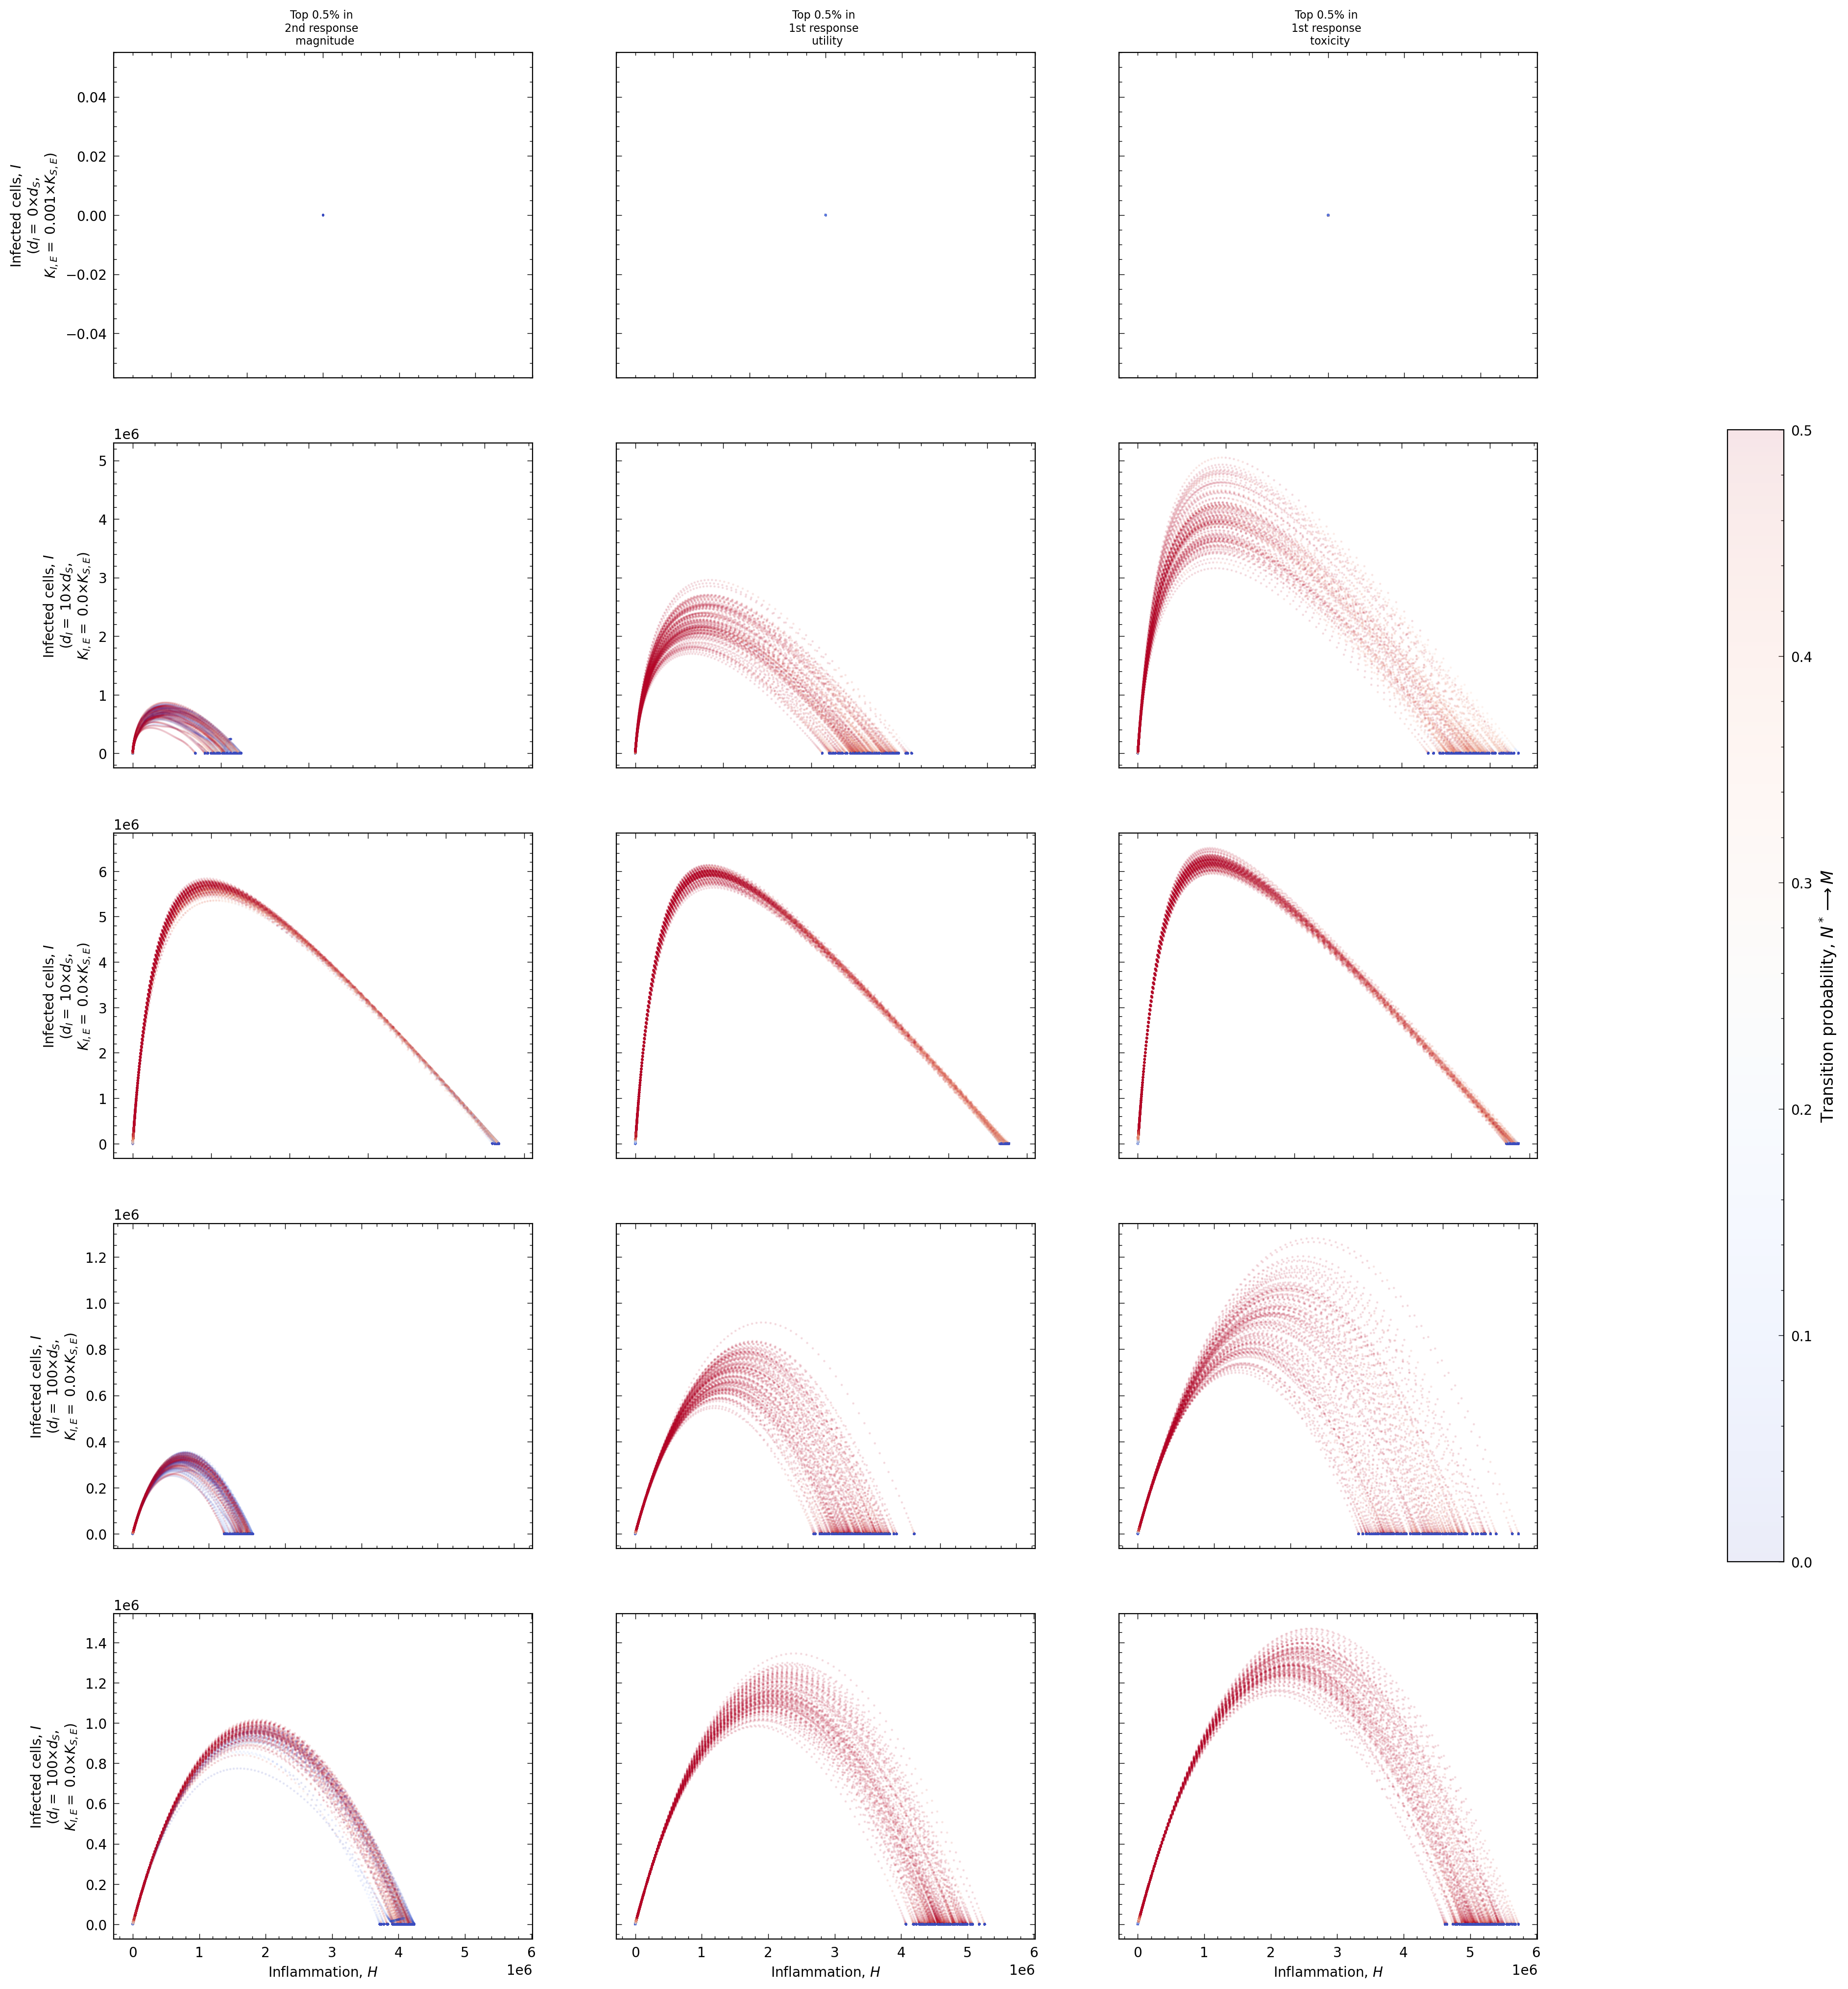

In [5]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs, n, figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for i, category in enumerate(perf_categories[0:n]):
        k = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        p_data = np.array(p_diff_data_for_dmd[diff_index])
        s_data = np.array(s_diff_data_for_dmd[diff_index])
        
        dyn_data = np.array(dyn_data_for_dmd[diff_index])
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,:,0], dyn_data[:,:,-10], dyn_data[:,:,1], dyn_data[:,:,-9], dyn_data[:,:,-8], dyn_data[:,:,-7], dyn_data[:,:, 4], dyn_data[:,:,-6], dyn_data[:,:,5], dyn_data[:,:, -5], dyn_data[:,:,6], dyn_data[:,:,-4], dyn_data[:,:,7], dyn_data[:,:,-3], dyn_data[:,:,8], dyn_data[:,:,-2], dyn_data[:,:,9], dyn_data[:,:,-1]
            
            #axs[l,i].plot(pH, pI, 'k-', lw = 0.2)
            im = axs[l,i].scatter(pH, pI, marker = '.', s = 2.5,
                                  c = p_data[:,:,0], cmap='coolwarm', 
                                  alpha = 0.1)
                
        if i == 0:
            axs[l,0].set_ylabel("Infected cells, $I$ \n"+r"($d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$)", fontsize = 10)
        
        axs[0,i].set_title(r'Top '+str(np.round((1-cutoff)*100, 3))+'%'+' in \n'+perf_labels[i-1], fontsize = 8)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.1)
cb.set_label(r'Transition probability, $N^* \longrightarrow M$', fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"Inflammation, $H$", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

plt.savefig('_figs/'+comment+'-prim_diff_dynamics_by_category'+'.png', dpi=300, bbox_inches="tight")

5it [00:00, 65.21it/s]


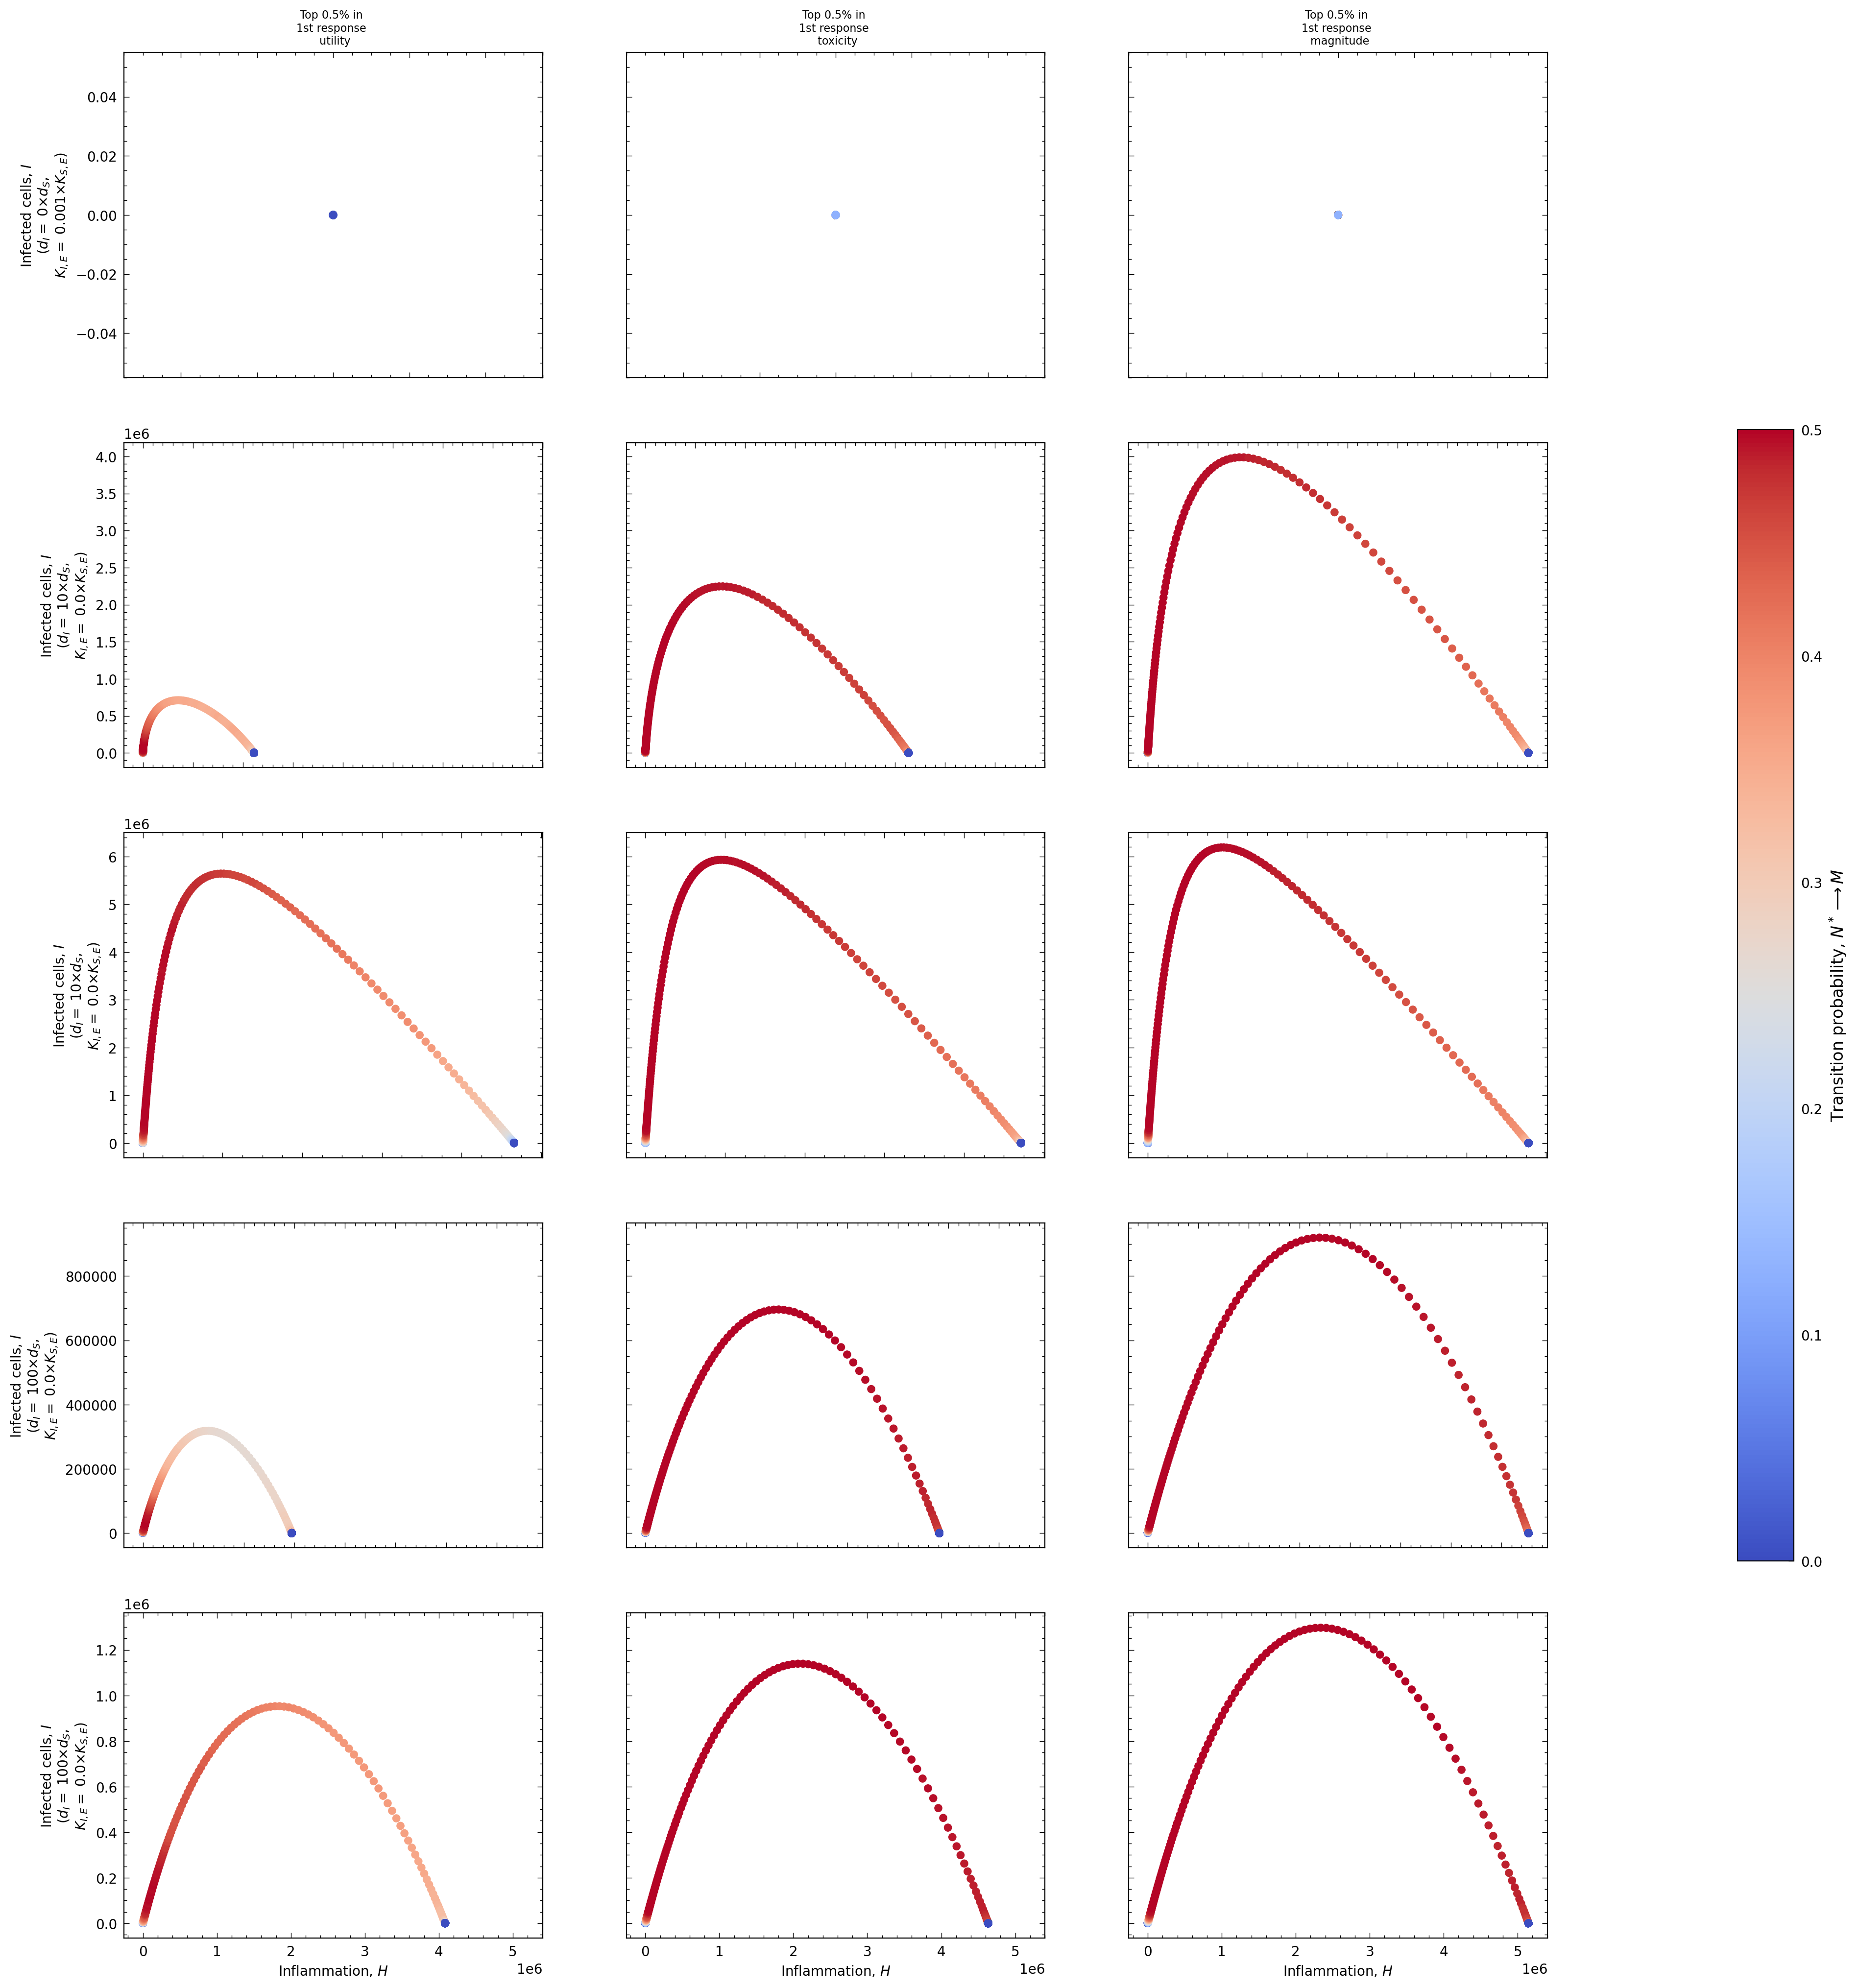

In [9]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs, n, figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for i, category in enumerate(perf_categories[0:n]):
        k = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        p_data = np.mean(np.array(p_diff_data_for_dmd[diff_index]), axis = 0)
        s_data = np.mean(np.array(s_diff_data_for_dmd[diff_index]), axis = 0)
        
        dyn_data = np.mean(np.array(dyn_data_for_dmd[diff_index]), axis = 0)
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,-7], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9], dyn_data[:,-1]

            im = axs[l,i].scatter(pH, pI, marker = 'o', 
                                  c = p_data[:,0], cmap='coolwarm')
                
        if i == 0:
            axs[l,0].set_ylabel("Infected cells, $I$ \n"+r"($d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$)", fontsize = 10)
        
        axs[0,i].set_title(r'Top '+str(np.round((1-cutoff)*100, 3))+'%'+' in \n'+perf_labels[i], fontsize = 8)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.1)
cb.set_label(r'Transition probability, $N^* \longrightarrow M$', fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"Inflammation, $H$", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()
        
plt.savefig('_figs/'+comment+'-prim_mean_diff_dynamics_by_category'+'.png', dpi=300, bbox_inches="tight")

5it [00:00, 73.63it/s]


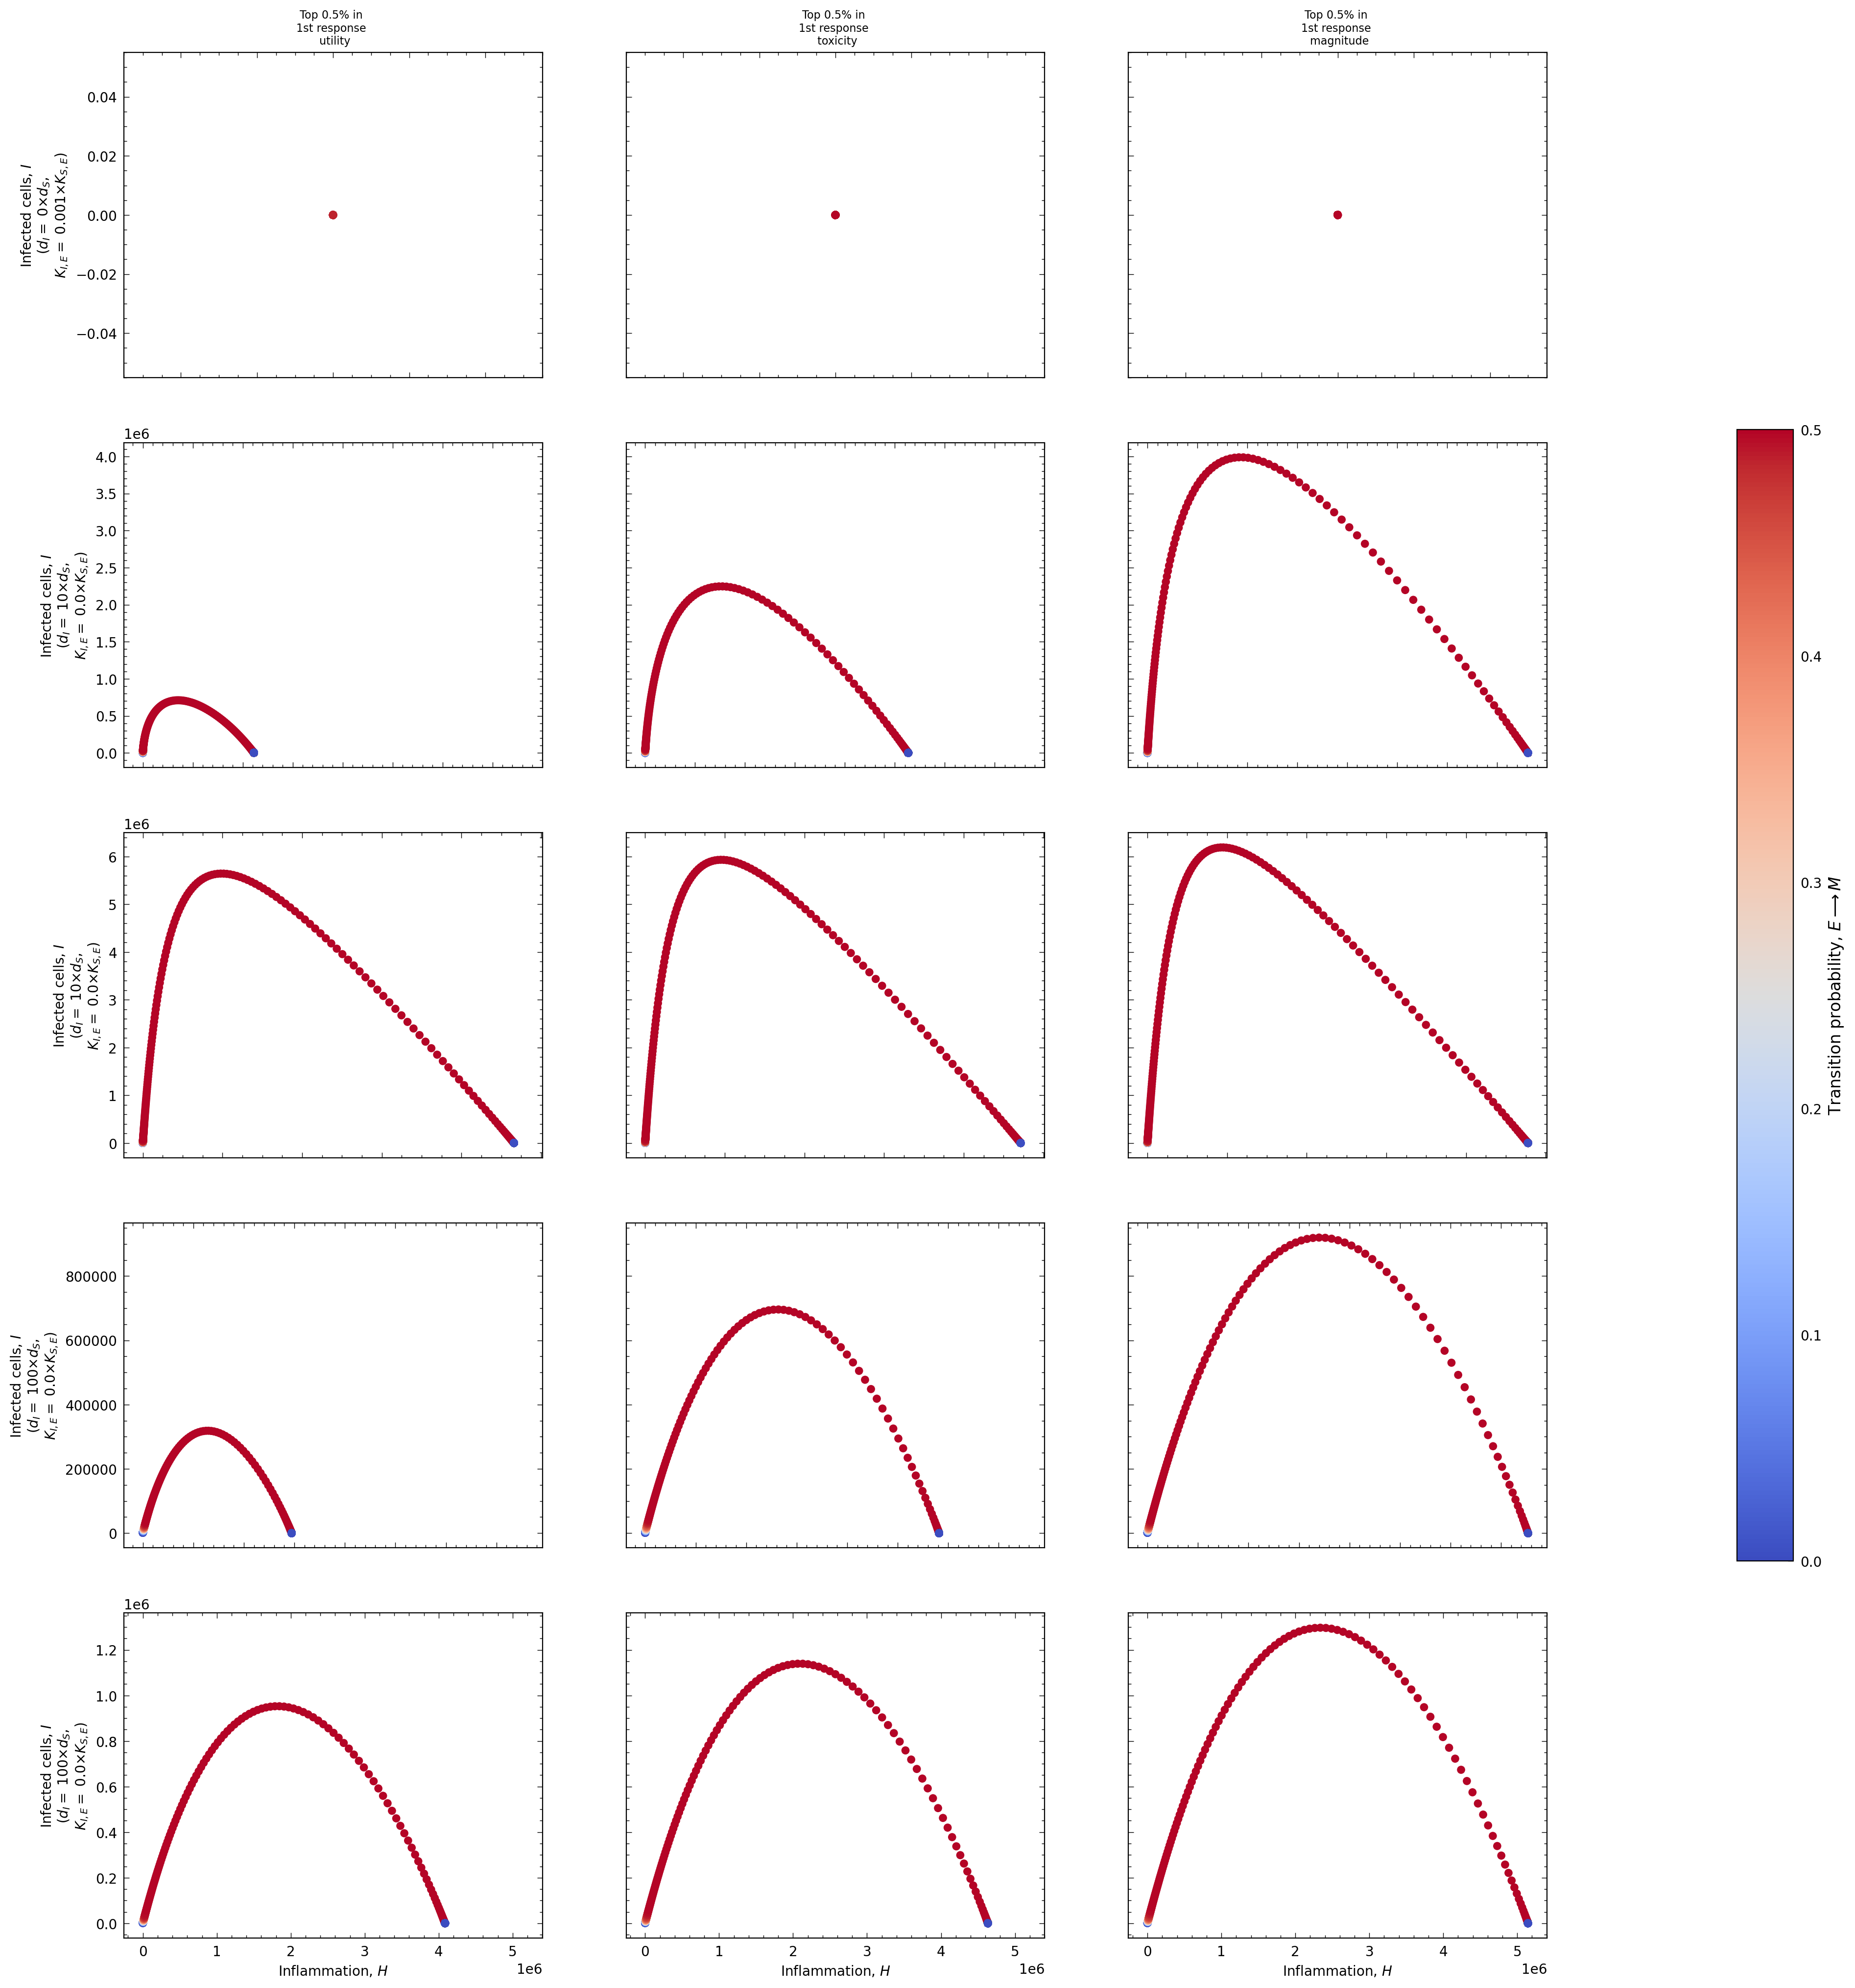

In [10]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs,len(perf_categories[0:n]), figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for i, category in enumerate(perf_categories[0:n]):
        k = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        p_data = np.mean(np.array(p_diff_data_for_dmd[diff_index]), axis = 0)
        s_data = np.mean(np.array(s_diff_data_for_dmd[diff_index]), axis = 0)
        
        dyn_data = np.mean(np.array(dyn_data_for_dmd[diff_index]), axis = 0)
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,-7], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9], dyn_data[:,-1]

            im = axs[l,i].scatter(pH, pI, marker = 'o', 
                                  c = p_data[:,1], cmap='coolwarm')
                
        if i == 0:
            axs[l,0].set_ylabel("Infected cells, $I$ \n"+r"($d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$)", fontsize = 10)
        
        axs[0,i].set_title(r'Top '+str(np.round((1-cutoff)*100, 3))+'%'+' in \n'+perf_labels[i], fontsize = 8)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.1)
cb.set_label(r'Transition probability, $E \longrightarrow M$', fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"Inflammation, $H$", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()
        
plt.savefig('_figs/mean_diff_dynamics_by_category_EeM', dpi=300, bbox_inches='tight')

In [ ]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs,len(perf_categories[0:4]), figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for k, category in enumerate(perf_categories[:n]):
        j = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = k + num_categories*j
        p_data = np.mean(np.array(p_diff_data_for_dmd[diff_index]), axis = 0)
        s_data = np.mean(np.array(s_diff_data_for_dmd[diff_index]), axis = 0)

        dyn_data = np.mean(np.array(dyn_data_for_dmd[diff_index]), axis = 0)

        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,-7], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9], dyn_data[:,-1]
            inst_dI = np.array([0 if i == 0 else pI_d_I[i] - pI_d_I[i-1] for i in np.arange(0,pI_d_I.shape[0])]).T
            inst_dS = np.array([0 if i == 0 else pI_d_S[i] - pI_d_S[i-1] for i in np.arange(0,pI_d_S.shape[0])]).T
            no_eff_pI_d_I = no_eff_data[j]['cell_time_series'][:,8][keep]
            no_eff_pI_d_S = no_eff_data[j]['cell_time_series'][:,9][keep]
            no_eff_pS = no_eff_data[j]['cell_time_series'][:,0][keep]
            no_eff_inst_dI = np.array([0 if i == 0 else no_eff_pI_d_I[i] - no_eff_pI_d_I[i-1] for i in np.arange(0,no_eff_pI_d_I.shape[0])]).T
            no_eff_inst_dS = np.array([0 if i == 0 else no_eff_pI_d_S[i] - no_eff_pI_d_S[i-1] for i in np.arange(0,no_eff_pI_d_S.shape[0])]).T
            
            axs[l,k].plot(time, inst_dI - no_eff_inst_dI, 'k-', lw = 1.5,
                    label = r'1st marginal killed infected')
            im = axs[l,k].scatter(time, inst_dI - no_eff_inst_dI, marker = 'o', c = pE/K_IE, cmap='coolwarm')
            
            axs[l,k].plot(time, inst_dS - no_eff_inst_dS, 'k--', lw = 1.5,
                        label = r'1st marginal killed susceptible')
            axs[l,k].scatter(time, inst_dS - no_eff_inst_dS, marker = 'o', c = pE/K_IE, cmap='coolwarm')
            #axs[l,k].semilogy()

            ax2 = axs[l,k].twinx()  # instantiate a second axes that shares the same x-axis
            S_min_over_S_0 = np.round(np.min(pS/S_0),2)
            ax2.plot(time, (pS-no_eff_pS)/S_0, 'm-',label = r"$min\{ \frac{S_p}{S_0}\} =$ "+str(S_min_over_S_0), lw = 2.0)
            ax2.legend(loc = "upper left",fontsize = 7)
            ax2.set_ylim([-1/10, 1/2])
            if k == n-1:
                ax2.set_ylabel('1st marginal \n surviving \nsusceptible', fontsize = 10)  # we already handled the x-label with ax1
                ax2.tick_params(axis='y')
            else:
                ax2.set_yticklabels([])
            
    
            [axs[l,k].axvline(x=time[i], linestyle='-', linewidth=0.3, color='limegreen', alpha=pH[i]/(pH[i] + K_EH), zorder = 0) for i in np.arange(0, len(pH)-1)]
               
        if k == 0:
            axs[l,0].set_ylabel(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(format(K_IE/K_SE,'.0e'))+r"$\times K_{S,E}$", fontsize = 10)
        
        if l == 0:
            if k == 0:
                axs[0,k].set_title('Biologically \n motivated', fontsize = 8)
            else:
                axs[0,k].set_title(r'Top '+str(int((1-cutoff)*100))+'%'+' in \n'+perf_labels[k-1], fontsize = 8)

axs[0,0].axvline(x=time[np.argmax(pH)], linestyle='-', linewidth=0.3, color='limegreen', alpha=pH[np.argmax(pH)]/(pH[np.argmax(pH)]+K_EH), label =r"Inflammation, $H_p$")
axs[0,0].legend(loc='center right', bbox_to_anchor=(10.0, 0.7), fontsize = 14)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.1)
cb.set_label("Infection load", fontsize = 12)

    
for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"time, $t$ (days)", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

fig.tight_layout()
        
plt.savefig('_figs/mean_pIS_dynamics_by_categories', dpi=300, bbox_inches='tight')

In [ ]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs,len(perf_categories[0:n]), figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for k, catx in enumerate(np.arange(n,num_categories)):
        category = perf_categories[catx]
        j = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = catx + num_categories*j
        p_data = np.mean(np.array(p_diff_data_for_dmd[diff_index]), axis = 0)
        s_data = np.mean(np.array(s_diff_data_for_dmd[diff_index]), axis = 0)

        dyn_data = np.mean(np.array(dyn_data_for_dmd[diff_index]), axis = 0)

        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,0], dyn_data[:,-10], dyn_data[:,1], dyn_data[:,-9], dyn_data[:,-8], dyn_data[:,-7], dyn_data[:, 4], dyn_data[:,-6], dyn_data[:,5], dyn_data[:, -5], dyn_data[:,6], dyn_data[:,-4], dyn_data[:,7], dyn_data[:,-3], dyn_data[:,8], dyn_data[:,-2], dyn_data[:,9], dyn_data[:,-1]
            inst_dI = np.array([0 if i == 0 else sI_d_I[i] - sI_d_I[i-1] for i in np.arange(0,sI_d_I.shape[0])]).T
            inst_dS = np.array([0 if i == 0 else sI_d_S[i] - sI_d_S[i-1] for i in np.arange(0,sI_d_S.shape[0])]).T
            no_eff_sI_d_I = no_eff_data[j]['cell_time_series'][:,-2][keep]
            no_eff_sI_d_S = no_eff_data[j]['cell_time_series'][:,-1][keep]
            no_eff_pS = no_eff_data[j]['cell_time_series'][:,-10][keep]
            no_eff_inst_dI = np.array([0 if i == 0 else no_eff_sI_d_I[i] - no_eff_sI_d_I[i-1] for i in np.arange(0,no_eff_sI_d_I.shape[0])]).T
            no_eff_inst_dS = np.array([0 if i == 0 else no_eff_sI_d_S[i] - no_eff_sI_d_S[i-1] for i in np.arange(0,no_eff_sI_d_S.shape[0])]).T
            
            axs[l,k].plot(time, inst_dI - no_eff_inst_dI, 'k-', lw = 1.5,
                    label = '2nd marginal killed infected')
            im = axs[l,k].scatter(time, inst_dI - no_eff_inst_dI, marker = 'o', c = pE/K_IE, cmap='coolwarm')
            
            axs[l,k].plot(time, inst_dS - no_eff_inst_dS, 'k--', lw = 1.5,
                        label = '2nd marginal killed susceptible')
            axs[l,k].scatter(time, inst_dS - no_eff_inst_dS, marker = 'o', c = pE/K_IE, cmap='coolwarm')

            ax2 = axs[l,k].twinx()  # instantiate a second axes that shares the same x-axis
            S_min_over_S_0 = np.round(np.min(sS/S_0),2)
            ax2.plot(time, (sS-no_eff_pS)/S_0, 'm-',label = r"$min\{ \frac{S_s}{S_0}\} =$ "+str(S_min_over_S_0), lw = 2.0)
            ax2.legend(loc = "upper left",fontsize = 7)
            ax2.set_ylim([-1/4, 1/2])
            if k == int(len(perf_categories)/2):
                ax2.set_ylabel('2nd marginal \n surviving \n susceptible', fontsize = 10)  # we already handled the x-label with ax1
                ax2.tick_params(axis='y')
            else:
                ax2.set_yticklabels([])
            
    
            [axs[l,k].axvline(x=time[i], linestyle='-', linewidth=0.3, color='limegreen', alpha=sH[i]/(sH[i] + K_EH), zorder = 0) for i in np.arange(0, len(sH)-1)]
               
        if k == 0:
            axs[l,0].set_ylabel(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(format(K_IE/K_SE,'.0e'))+r"$\times K_{S,E}$", fontsize = 10)
        
        if l == 0:
            if k == 0:
                axs[0,k].set_title('Biologically \n motivated', fontsize = 8)
            else:
                axs[0,k].set_title(r'Top '+str(int((1-cutoff)*100))+'%'+' in \n'+perf_labels[catx-1], fontsize = 8)

axs[0,0].axvline(x=time[np.argmax(sH)], linestyle='-', linewidth=0.3, color='limegreen', alpha=sH[np.argmax(sH)]/(K_EH + sH[np.argmax(sH)]), label =r"Inflammation, $H_s$")
axs[0,0].legend(loc='center right', bbox_to_anchor=(10.0, 0.7), fontsize = 14)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.1)
cb.set_label("Infection load", fontsize = 12)
    
for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"time, $t$ (days)", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

fig.tight_layout()
        
plt.savefig('_figs/mean_sIS_dynamics_by_categories', dpi=300, bbox_inches='tight')

In [ ]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs,len(perf_categories[0:4]), figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for i, category in enumerate(perf_categories[:5]):
        k = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        
        p_data = np.array(p_diff_data_for_dmd[diff_index])
        dyn_data = np.array(dyn_data_for_dmd[diff_index])
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,:,0], dyn_data[:,:,-10], dyn_data[:,:,1], dyn_data[:,:,-9], dyn_data[:,:,-8], dyn_data[:,:,-7], dyn_data[:,:, 4], dyn_data[:,:,-6], dyn_data[:,:,5], dyn_data[:,:, -5], dyn_data[:,:,6], dyn_data[:,:,-4], dyn_data[:,:,7], dyn_data[:,:,-4], dyn_data[:,:,8], dyn_data[:,:,-2], dyn_data[:,:,9], dyn_data[:,:,-1]

            p_NE_data = np.mean(np.array(p_diff_data_for_dmd[diff_index])[:,:,0]*N/np.tile(np.sum(N,axis = 1), reps = (pnts,1)).T, axis = 0)
            p_EeM_data = np.mean(0.5*(np.array(p_diff_data_for_dmd[diff_index])[:,:,1] + np.array(p_diff_data_for_dmd[diff_index])[:,:,2])*pE/np.tile(np.sum(pE,axis = 1), reps = (pnts,1)).T, axis = 0)
    
            axs[l,i].plot(time, p_NE_data, 'k-', lw = 1.5,
                        label = r'Bias$_t(N^* \longrightarrow E)$')
            im = axs[l,i].scatter(time, p_NE_data, marker = 'o', c = np.mean(pI, axis = 0)/S_0, cmap='coolwarm')
            
            axs[l,i].plot(time, p_EeM_data, 'k--', lw = 1.5,
                        label = r'Bias$_t(E \longrightarrow eM)$')
            axs[l,i].scatter(time, p_EeM_data, marker = 'o', c = np.mean(pI, axis = 0)/S_0, cmap='coolwarm')
    
            [axs[l,i].axvline(x=time[j], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.mean(pH[:,j])/(K_EH + np.mean(pH[:,j])), zorder = 0) for j in np.arange(0, pnts-1)]
        
                
        if i == 0:
            axs[l,0].set_ylabel(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$", fontsize = 10)
        
        if l == 0:
            if i == 0:
                axs[0,i].set_title('Biologically \n motivated', fontsize = 8)
            else:
                axs[0,i].set_title(r'Top '+str(int((1-cutoff)*100))+'%'+' in \n'+perf_labels[i-1], fontsize = 8)

axs[0,0].axvline(x=time[np.argmax(np.mean(pH, axis = 0))], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.max(np.mean(pH, axis = 0))/(K_EH + np.max(np.mean(pH, axis = 0))), label =r"Inflammation, $H$")
axs[0,0].legend(loc='center right', bbox_to_anchor=(7.5, 0.7), fontsize = 14)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.05)
cb.set_label("Infection load", fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"time, $t$ (days)", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

plt.savefig('_figs/mean_effective_diff_dynamics_by_category', dpi=300, bbox_inches='tight')

In [ ]:
n = int(num_categories/2)
fig, axs = plt.subplots(n_virs,len(perf_categories[0:4]), figsize=(n_virs**2, n_virs**2), sharex='row', sharey='row')
time = np.linspace(0, sim_duration, int(sim_steps) + 1)[keep]

for l, (d_I, K_IE) in tqdm(enumerate(virs)):

    for i, category in enumerate(perf_categories[:5]):
        k = np.where((virs[:,0] == d_I)*(virs[:,1] == K_IE))[0].item()
        diff_index = i + num_categories*k
        
        p_data = np.array(p_diff_data_for_dmd[diff_index])
        dyn_data = np.array(dyn_data_for_dmd[diff_index])
        if np.isnan(dyn_data).all() == False:
            pS, sS, pI, sI, Ain, N, pE, sE, pM, sM, pM, sM, pH, sH, pI_d_I, sI_d_I, pI_d_S, sI_d_S = dyn_data[:,:,0], dyn_data[:,:,-10], dyn_data[:,:,1], dyn_data[:,:,-9], dyn_data[:,:,-8], dyn_data[:,:,-7], dyn_data[:,:, 4], dyn_data[:,:,-6], dyn_data[:,:,5], dyn_data[:,:, -5], dyn_data[:,:,6], dyn_data[:,:,-4], dyn_data[:,:,7], dyn_data[:,:,-4], dyn_data[:,:,8], dyn_data[:,:,-2], dyn_data[:,:,9], dyn_data[:,:,-1]

            im = axs[l,i].scatter(time, np.mean(N, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='s', cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
            axs[l,i].plot(time, np.mean(N, axis = 0), 'k--')
            
            axs[l,i].scatter(time, np.mean(pE, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='o', cmap='coolwarm', 
                        label = r'Effector, $E$')
            axs[l,i].plot(time, np.mean(pE, axis = 0), 'k--')
            
            axs[l,i].scatter(time, np.mean(pM + pM, axis = 0), c =np.mean(pI, axis = 0)/S_0, marker ='*', cmap='coolwarm',
                        label = r'Memory, $cM+eM$')
            axs[l,i].plot(time, np.mean(pM + pM, axis = 0), 'k--')

            axs[l,i].semilogy()
            
            [axs[l,i].axvline(x=time[j], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.mean(pH[:,j])/(K_EH + np.mean(pH[:,j])), zorder = 0) for j in np.arange(0, pnts-1)]
        
                
        if i == 0:
            axs[l,0].set_ylabel(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+",\n"+r"$K_{I,E} =$ "+str(np.round(K_IE/K_SE,3))+r"$\times K_{S,E}$", fontsize = 10)
        
        if l == 0:
            if i == 0:
                axs[0,i].set_title('Biologically \n motivated', fontsize = 8)
            else:
                axs[0,i].set_title(r'Top '+str(int((1-cutoff)*100))+'%'+' in \n'+perf_labels[i-1], fontsize = 8)

axs[0,0].axvline(x=time[np.argmax(np.mean(pH, axis = 0))], linestyle='-', linewidth=0.3, color='limegreen', alpha=np.max(np.mean(pH, axis = 0))/(K_EH + np.max(np.mean(pH, axis = 0))), label =r"Inflammation, $H$")
axs[0,0].legend(loc='center right', bbox_to_anchor=(7.5, 0.7), fontsize = 14)

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.05)
cb.set_label("Infection load", fontsize = 12)

for i, ax in enumerate(axs.flat):
    ax.set_xlabel(r"time, $t$ (days)", fontsize = 10)

for ax in axs.flat:
    ax.label_outer()

plt.savefig('_figs/mean_cell_dynamics_by_category', dpi=300, bbox_inches='tight')

In [ ]:
# Plot UMAP
import umap

fig, axs = plt.subplots(rows, int(np.ceil(n_virs/rows)), figsize=(n_virs + 1, n_virs*rows/2), sharex='col', sharey=False)

for l, (d_I, K_IE) in enumerate(virs):

    reducer = umap.UMAP()
    x,y = int(np.floor(rows*l/n_virs)), l % int(np.ceil((n_virs/rows)))

    perf_data = clustered_mean_df[(clustered_mean_df['d_I'] == d_I)*(clustered_mean_df['K_IE'] == K_IE)]
    scaled_per_data = StandardScaler().fit_transform(perf_data[perf_vars[4:]].values)

    embedding = reducer.fit_transform(scaled_per_data)
    
    S_min_over_S_0 = np.round(np.max(perf_data['min_sS']/perf_data['S_0']),2)

    im = axs[x,y].scatter(embedding[:, 0], embedding[:, 1], 
                 c = perf_data[reg[0]], cmap='coolwarm_r', s = 15, marker ='s',zorder=0, alpha = 0.5)
    
    axs[x,y].scatter(embedding[perf_data['bio_reg'] == 1, 0], embedding[perf_data['bio_reg'] == 1, 1], 
                color ='gold', s = 50, marker ='X', zorder=1, edgecolor = 'k', linewidth = 0.3, label = "Experimentally\n motivated")
        
        
    axs[x,y].set_title(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+r", $K_{IE} =$ "+str(format(K_IE/K_SE,'.0e'))+r"$\times K_{S,E}$"+'\n'+r"$min_{\psi}~\{ \frac{S_{min}}{S_0}\} =$ "+str(S_min_over_S_0), fontsize = 7)

    #axs[x,y].semilogx()

axs[0,0].legend()

cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6, pad = 0.075)
cb.set_label("Regulatory weight", fontsize = 12)
    
for j, ax in enumerate(axs.flat):
    if j % int(np.ceil(n_virs/rows)) == 0:
        ax.set_ylabel("UMAP 2", fontsize = 10)
    else:
        ax.set(ylabel="")
    if j >= n_virs - int(np.ceil(n_virs/rows)):
        ax.set_xlabel("UMAP 1", fontsize = 10)
    else:
        ax.set(xlabel="")
    
#plt.savefig('_figs/harm_sS_v_sE_smem'+'.png', dpi=300, bbox_inches="tight")